## Chute libre 

On réalise l'étude physique d'une chute libre (cas le plus classique en physique). On réalisera une représentation de sa trajectoire à l'aide de l'algorithme d'Euler. Par la suite, on ajoutera le 'bruit' comme paramètre d'étude, nous permettant ainsi d'obtenir un comparatif entre valeur théorique et réalité expérimentale.

---

# 1: Etude théorique de la chute libre.

Dans cette première partie, on utilise les données numériques obtenues précédemment à l'aide de l'algorithme d'Euler sur Fortran. Cette manipulation nous a permis d'extraire une base de donnée nommée 'chutelibre.dat'. On va alors récupérer ces données sur python et ainsi tracer les différentes positions du système en fonction du temps. 

a. import des modules et paramètres nécessaires 

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 

In [7]:
nomFichier= "chutelibre.dat"
z0 = 5.0  #en metres
v0 = 10.0 #en m/s 
g=9.81    #en m/s^2

b. définition des fonctions nécessaires 

In [8]:
def ztheo(t) : 
	return z0 + v0*t - 0.5*g*t**2 
	

def vtheo (t):
	return v0 - g*t 

c. récupération des données 

In [11]:
data=np.genfromtxt(nomFichier)

d. utilisation des données 

In [12]:
t = data[:,0]
z = data[:,1]
v = data[:,2] 

e. calcul des valeurs théoriques 

In [13]:
zT = ztheo(t)
vT = vtheo(t)

f. réalisation de la figure 

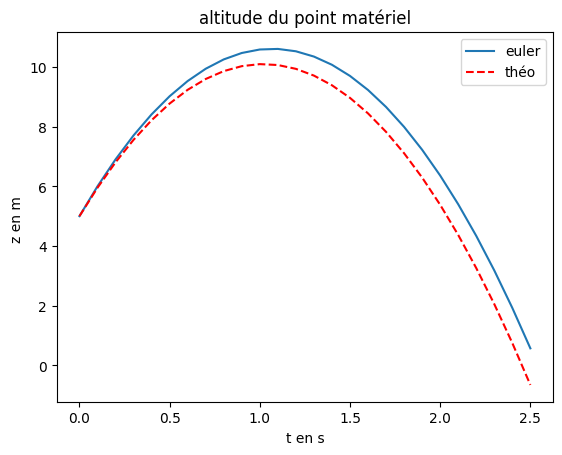

In [15]:
plt.figure(1)
plt.plot(t,z, label='euler')
plt.plot(t, zT,'r--', label='théo')
plt.title("altitude du point matériel")
plt.xlabel ("t en s") 
plt.ylabel ("z en m ") 
plt.legend()

Analyse : 
    On remarque que l'altitude du point matériel suit une trajectoire parabolique, la courbe associé au calcul de ses valeurs par l'algorithme d'Euler semble néanmoins s'écarter de la courbe théorique jusqu'à ce qu'elle atteigne son apogée en t= 1.1 secondes. De plus, lors de la redescente du point matériel, les valeurs obtenues par la méthode d'Euler semblent se rapprocher légèremment de la courbe théorique. Ainsi, la méthode d'Euler associé au cas de la chute libre admet son erreur la plus grande à l'apogée en altitude du point matériel néanmoins, elle garde le caractère parabolique de la trajectoire rendant cette méthode viable dans le cas présent.

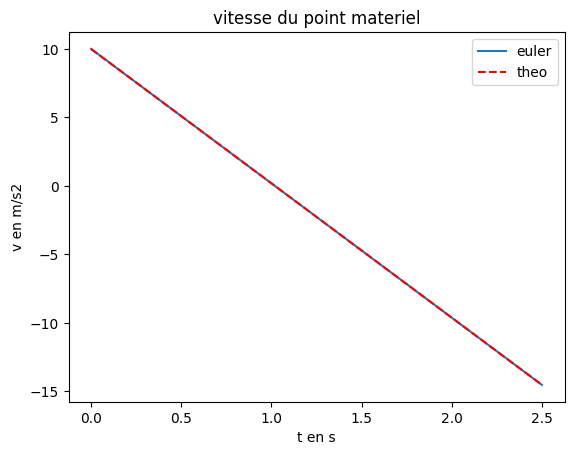

In [16]:
plt.figure(2)
plt.plot(t,v, label ='euler')
plt.plot(t, vT, 'r--', label = 'theo')
plt.title("vitesse du point materiel")
plt.xlabel ("t en s")
plt.ylabel("v en m/s2")
plt.legend()
plt.show() 

Analyse : Dans le cas de la vitesse du point matériel, l'Algorithme d'Euler est particulièrement approprié car on obtient exactement les mêmes valeurs de vitesse avec le calcul théorique qu'avec le calcul par Euler. Ainsi cet Algorithme est particulièrement adapté pour ce genre de calcul.

# 2: Ajout de bruit et comparaison avec le modèle de prédilection.

Dans cette partie, on ajoute la notion de bruit a notre graphe afin d'obtenir l'accord entre la partie théorique et la parti expérimentale.

a. ajout du bruit pour l'altitude 

In [17]:
noise = np.random.normal(0, 0.1, len(zT))
Z_noisy = zT + noise

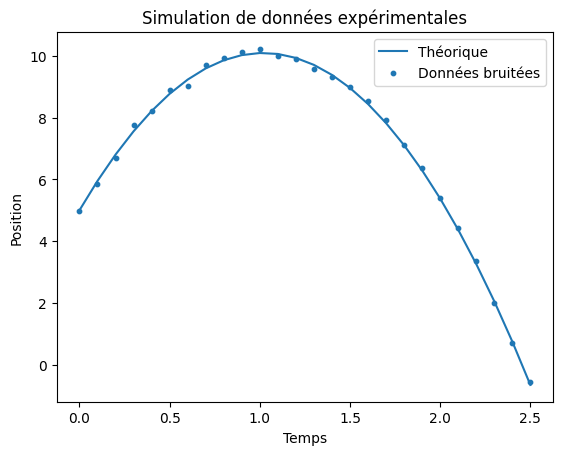

In [18]:
plt.figure()

plt.plot(t, zT, label="Théorique")
plt.scatter(t, Z_noisy, s=10, label="Données bruitées")

plt.xlabel("Temps")
plt.ylabel("Position")
plt.title("Simulation de données expérimentales")
plt.legend()
plt.show()

Analyse : On observe que les données expérimentales (points) fluctuent de manière aléatoire autour de la courbe théorique. Ces écarts simulent les incertitudes de mesures inhérentes à toute expérience réelle. Bien que la superposition semble visuellement plus précise sur la fin de la trajectoire, cela reste une caractéristique de bruit aléatoire généré. La prédiction théorique semble donc être un bon indicateurs de la position du point matériel en fonction du temps.

b. ajout de bruit pour la vitesse 

In [20]:
noise_v = np.random.normal(0, 0.1, len(vT))
V_noisy = vT + noise

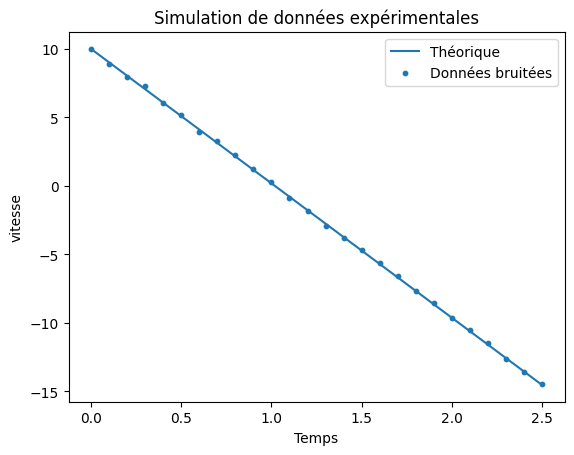

In [22]:
plt.figure()

plt.plot(t, vT, label="Théorique")
plt.scatter(t, V_noisy, s=10, label="Données bruitées")

plt.xlabel("Temps")
plt.ylabel("vitesse")
plt.title("Simulation de données expérimentales")
plt.legend()
plt.show()

Analyse: On observe une forte corrélation entre les points théoriques et les points expérimentaux, les écarts observés simulent les données d'un capteur de vitesse. La linéarité des données confirme que l'accéleration subie par l'objet est constante ce qui est caractéristique d'un champ de pesanteur uniforme.

# 3: Conclusion 

Pour conclure, afin d'analyser la trajectoire et la vitesse d'un point matériel en chute libre, les capteurs utilisés (ici représentés par le bruit) permettent d'obtenir un résultat viable et proche des valeurs théoriques, confirmant ainsi la précision du modèle théorique utilisé.